In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform

In [2]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.shape

(20640, 10)

In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [8]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].mean())

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [10]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

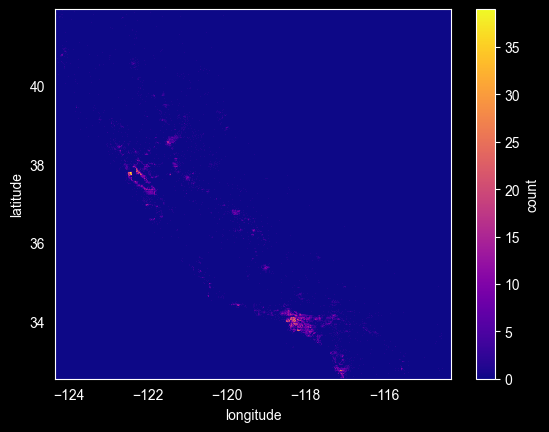

In [11]:
plt.hist2d(df["longitude"], df["latitude"], bins = 500, cmap ="plasma")
plt.colorbar(label='count')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.show()

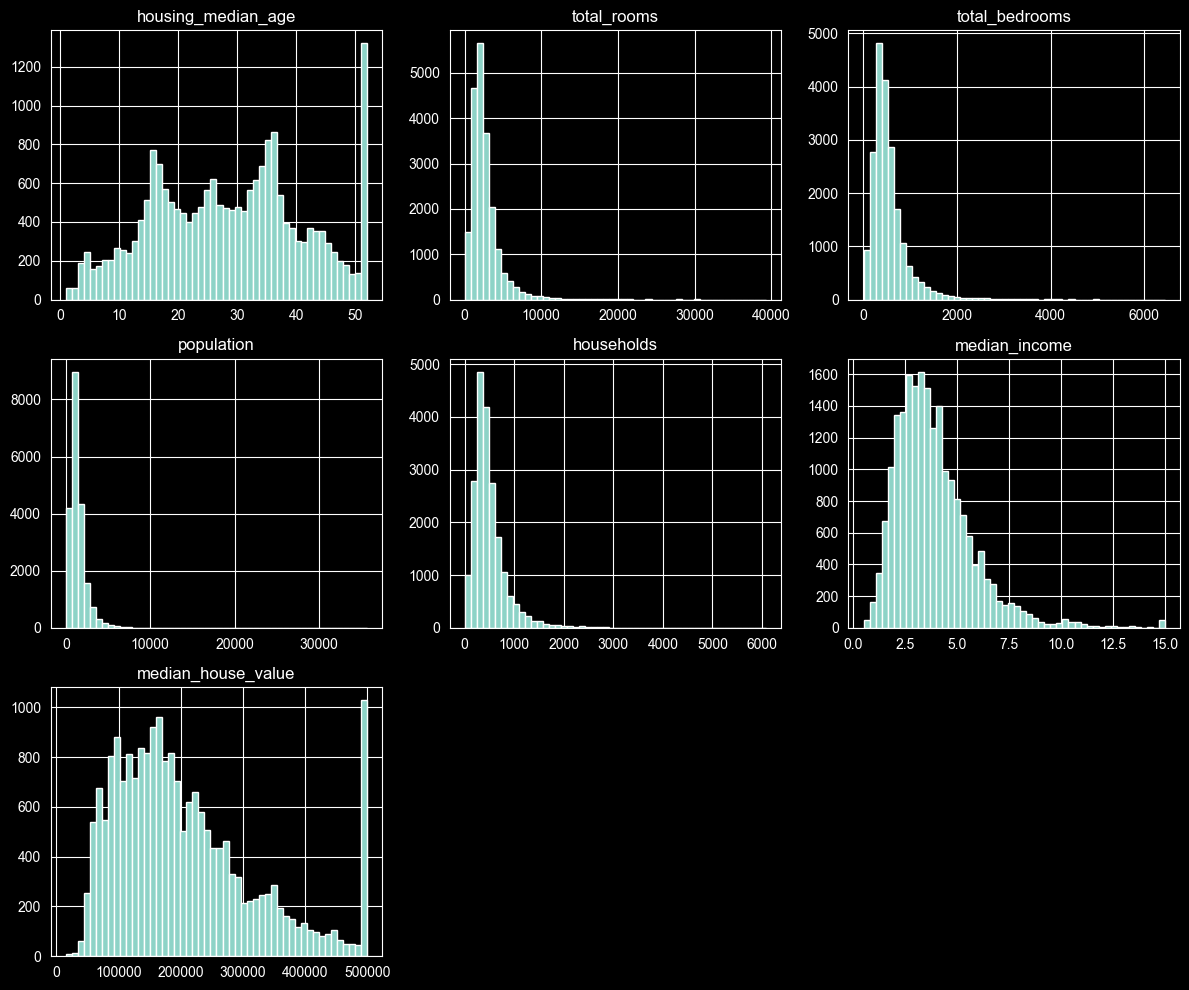

In [12]:
cols = ["housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income", "median_house_value"]
df[cols].hist(bins = 50, figsize = (12,10))
plt.tight_layout()
plt.show()

In [13]:
df['avg_rooms'] = df['total_rooms'] / df['households']
df['avg_bedrooms'] = df['total_bedrooms'] / df['households']
df['people_per_household'] = df['population'] / df['households']
df.drop(columns = ["total_bedrooms", "total_rooms"], inplace = True)

In [14]:
df.head()

,longitude,latitude,housing_median_age,population,households,median_income,median_house_value,ocean_proximity,avg_rooms,avg_bedrooms,people_per_household
0,-122.23,37.88,41.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,1.023810,2.555556
1,-122.22,37.86,21.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.971880,2.109842
2,-122.24,37.85,52.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,1.073446,2.802260
3,-122.25,37.85,52.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,1.073059,2.547945
4,-122.25,37.85,52.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,1.081081,2.181467


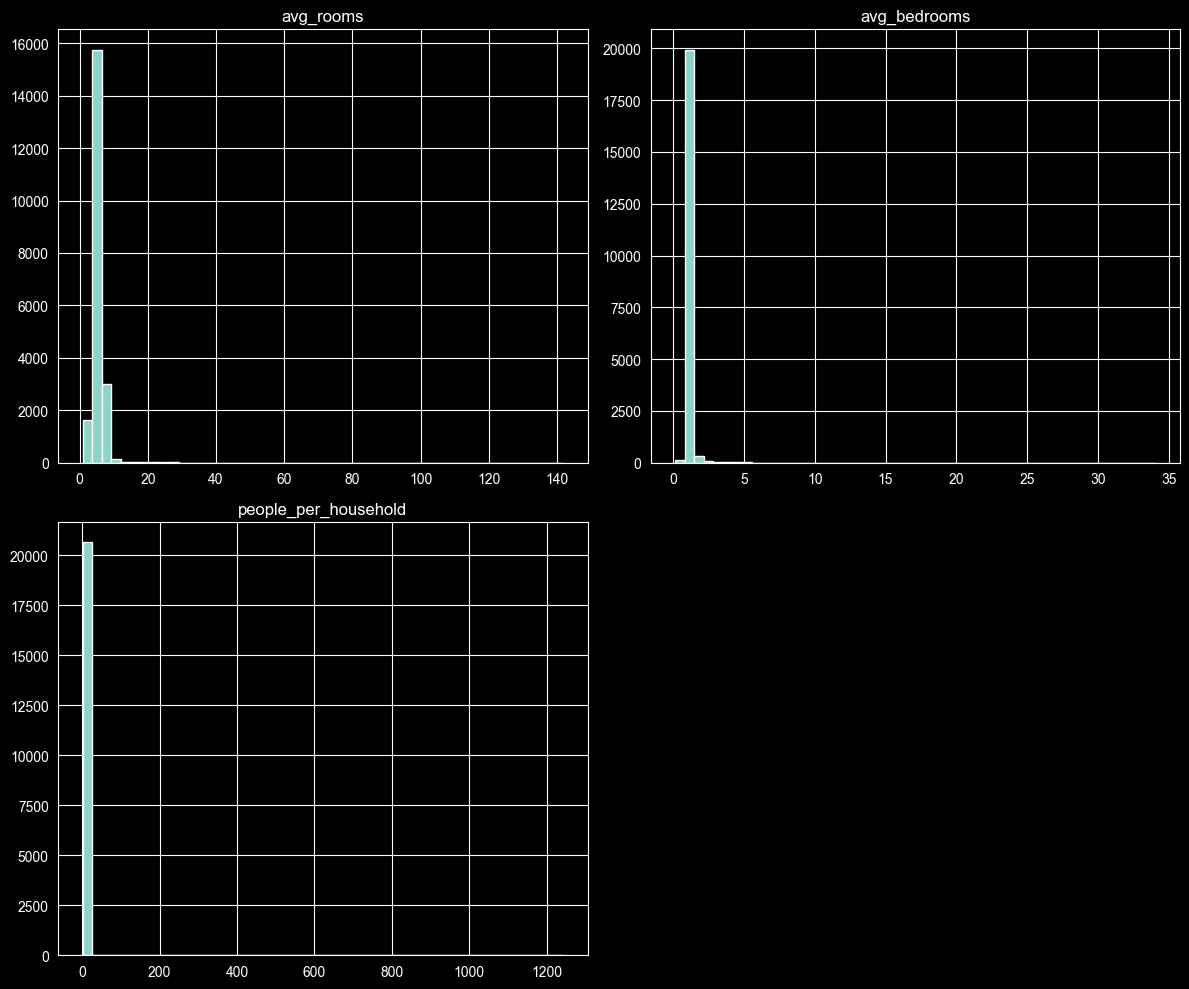

In [15]:
df[['avg_rooms','avg_bedrooms','people_per_household']].hist(bins = 50, figsize = (12,10))
plt.tight_layout()
plt.show()

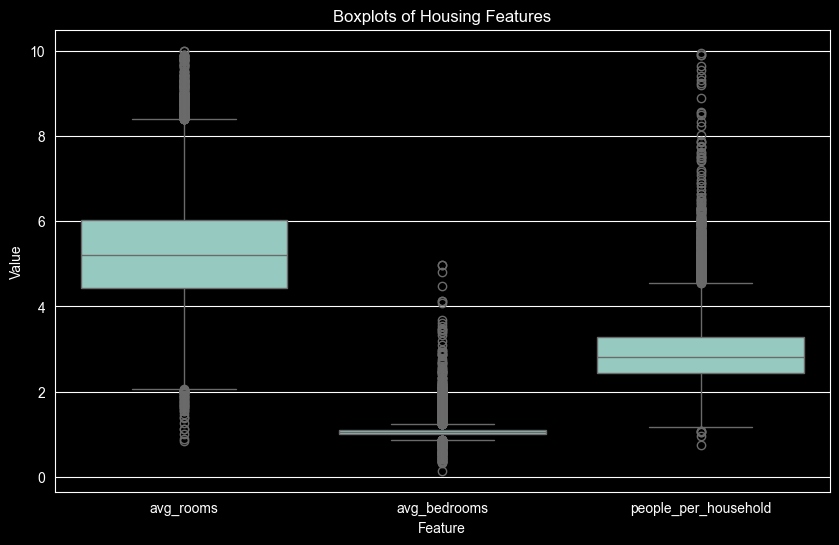

In [16]:
thresholds = {
    'avg_rooms': 10,
    'avg_bedrooms': 5,
    'people_per_household': 10,
}

for col, max_val in thresholds.items():
    df = df[df[col] <= max_val]


features = df[['avg_rooms', 'avg_bedrooms', 'people_per_household']]
df_melted = features.melt(var_name='Feature', value_name='Value')
plt.figure(figsize=(10,6))
sns.boxplot(x='Feature', y='Value', data=df_melted)
plt.title('Boxplots of Housing Features')
plt.show()


In [17]:
df.shape

(20370, 11)

In [18]:
df = df[df["median_house_value"] < 500000]
df = df[df['housing_median_age'] < 52]

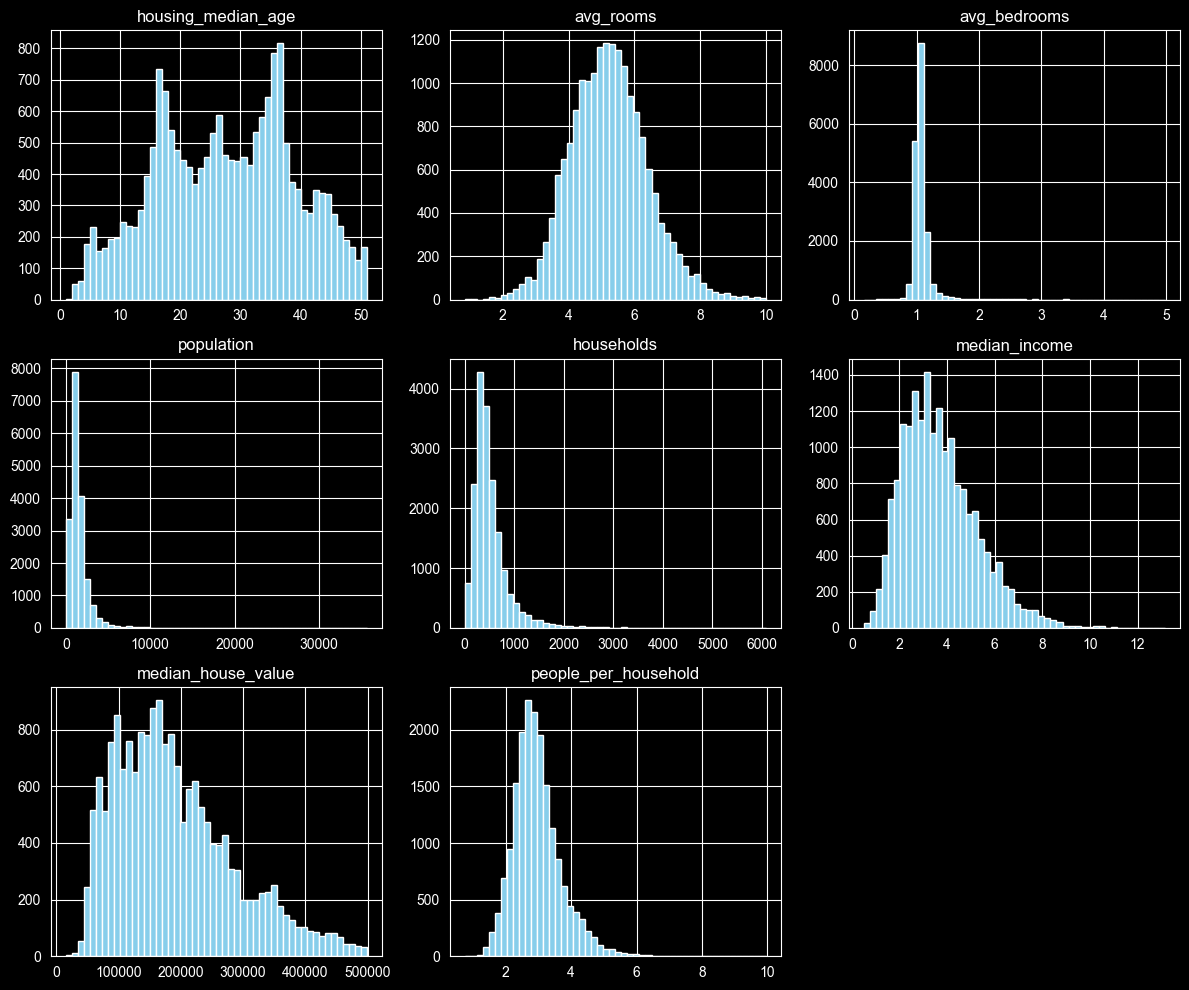

In [19]:
cols = ["housing_median_age", 'avg_rooms', 'avg_bedrooms', "population", "households", "median_income", "median_house_value", 'people_per_household']
df[cols].hist(bins = 50, figsize = (12,10), color = "skyblue")
plt.tight_layout()
plt.show()

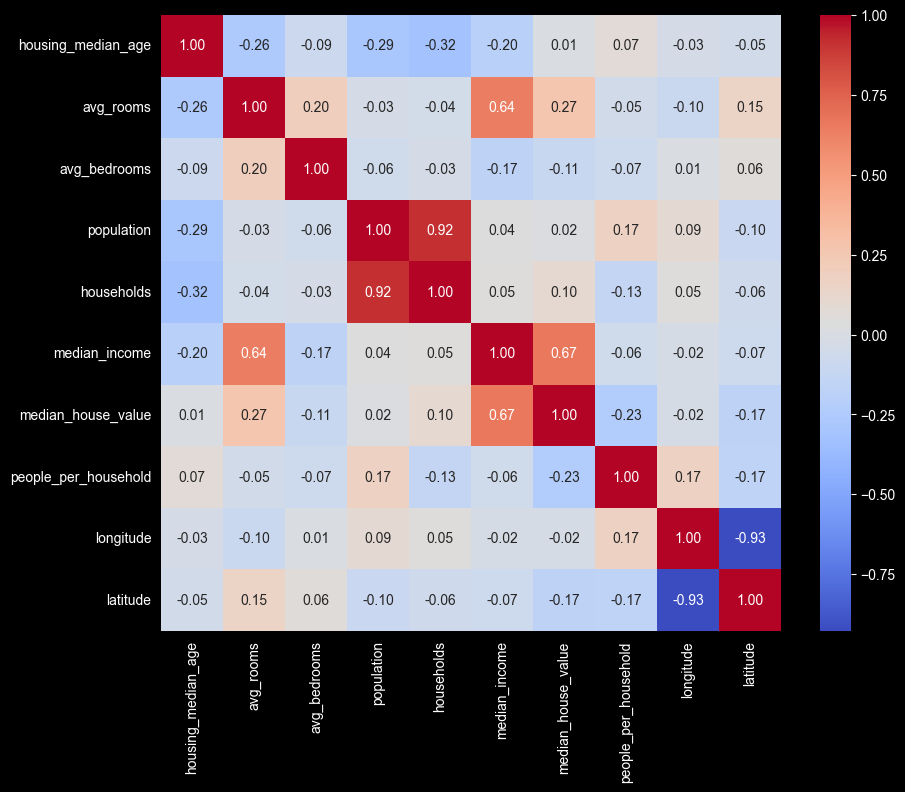

In [20]:
cols.append("longitude")
cols.append("latitude")
corr_matrix = df[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt = ".2f", cmap = "coolwarm")
plt.show()

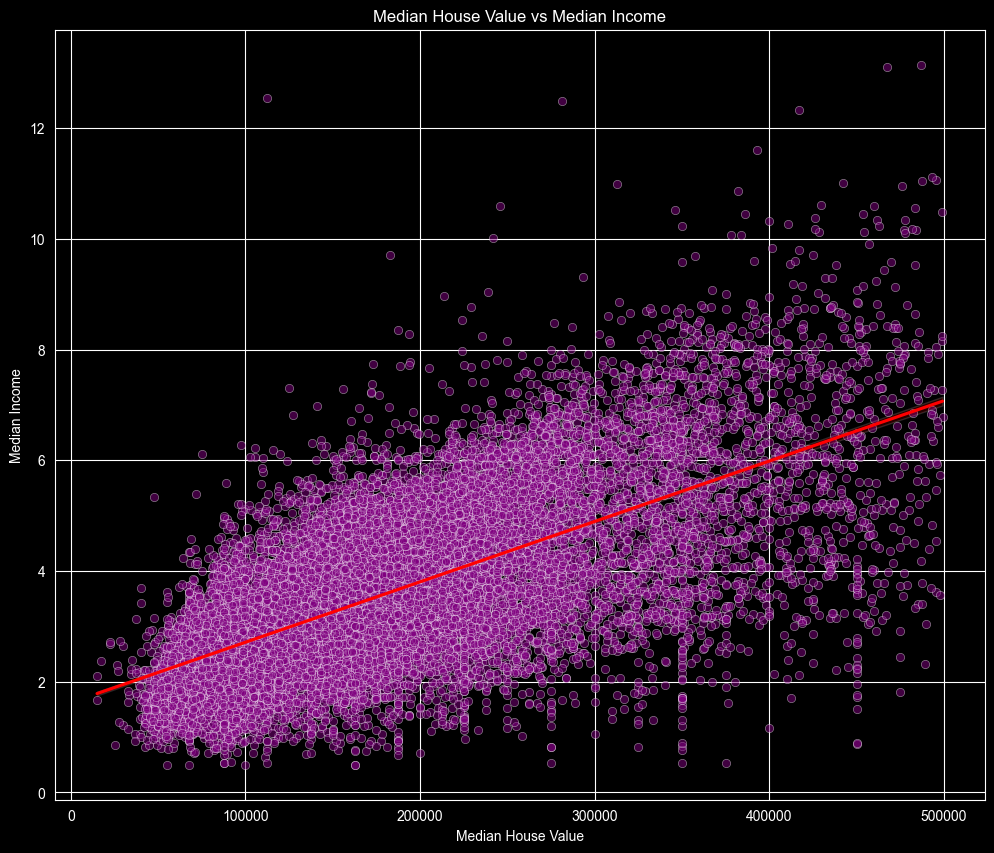

In [21]:
plt.figure(figsize=(12,10))
sns.scatterplot(data=df, x = "median_house_value", y= "median_income", color = "purple", alpha = 0.5)
sns.regplot(data=df, x = "median_house_value", y= "median_income", color = "red", scatter= False)
plt.xlabel("Median House Value")
plt.ylabel("Median Income")
plt.title("Median House Value vs Median Income")
plt.show()

In [22]:
from sklearn.linear_model import LinearRegression

x = df[[c for c in df.columns if c != "median_house_value" and c != "ocean_proximity"]]
y = df["median_house_value"]

x_train1, x_test1, y_train1, y_test1 = train_test_split(
    x, y, test_size = 0.2, random_state = 67
)

model_lr = LinearRegression()
model_lr.fit(x_train1, y_train1)

y_pred1 = model_lr.predict(x_test1)
model1_r2score = r2_score(y_test1, y_pred1)
model1_mse = mean_squared_error(y_test1, y_pred1)
print("R²:", model1_r2score)
print("MSE:", model1_mse)

R²: 0.6468683026887132
MSE: 3253502361.808322


In [23]:
from sklearn.linear_model import Lasso

x_train2, x_test2, y_train2, y_test2 = train_test_split(
    x, y, test_size = 0.2, random_state = 40
)

scaler = StandardScaler()
x_train2_scaled = scaler.fit_transform(x_train2)
x_test2_scaled = scaler.transform(x_test2)

parameters = {"alpha":[0.001, 0.01, 0.1, 1]}

grid = GridSearchCV(Lasso(random_state=42), parameters, cv=5, scoring="r2")
grid.fit(x_train2_scaled, y_train2)

print("Best alpha:", grid.best_params_)
lasso_best = grid.best_estimator_

Best alpha: {'alpha': 1}


In [24]:
y_pred2 = lasso_best.predict(x_test2_scaled)
model2_r2score = r2_score(y_test2, y_pred2)
model2_mse = mean_squared_error(y_test2, y_pred2)
print("R²:", model2_r2score)
print("MSE:", model2_mse)

R²: 0.6446150335622507
MSE: 3117926512.687355


In [ ]:
from sklearn.ensemble import RandomForestRegressor

x_train3, x_test3, y_train3, y_test3 = train_test_split(
    x, y, test_size=0.2, random_state=42
)

param_dict = {
    "n_estimators": randint(100,200),
    "max_depth": randint(3, 15),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": [ "sqrt", "log2"]
}

random_forest = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator= random_forest,
    param_distributions= param_dict,
    n_iter= 50,
    cv= 5,
    scoring= "r2",
    n_jobs= -1,
    random_state= 42,
    error_score='raise'
)

random_search.fit(x_train3, y_train3)
best_random_forest = random_search.best_estimator_
print("Best Hyperparameters:", random_search.best_params_)

In [ ]:
y_pred3 = best_random_forest.predict(x_test3)
model3_r2score = r2_score(y_test3, y_pred3)
model3_mse = mean_squared_error(y_test3, y_pred3)
print("R²:", model3_r2score)
print("MSE:", model3_mse)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

x_train4, x_test4, y_train4, y_test4 = train_test_split(
    x, y, test_size=0.2, random_state=42
)

param_dist = {
    'n_estimators': randint(100, 300),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'subsample': uniform(0.7, 0.3)
}

gradient_boosting_regressor = GradientBoostingRegressor(random_state=42)

random_search2 = RandomizedSearchCV(
    estimator= gradient_boosting_regressor,
    param_distributions=param_dist,
    n_iter= 50,
    cv= 5,
    scoring= 'r2',
    n_jobs= -1,
    random_state= 42,
    error_score= np.nan
)

random_search2.fit(x_train4, y_train4)
best_gbr = random_search2.best_estimator_
print("Best Hyperparameters:", random_search2.best_params_)

In [ ]:
for key, value in random_search2.best_params_.items():
    value = float(value)

param_scores_clean = {k: float(v) if isinstance(v, (np.float32, np.float64)) else int(v) if isinstance(v, (np.int32, np.int64)) else v
                      for k, v in random_search2.best_params_.items()}
print("Best Hyperparameters:", param_scores_clean)

In [ ]:
y_pred4 = best_gbr.predict(x_test4)
model4_r2score = r2_score(y_test4, y_pred4)
model4_mse = mean_squared_error(y_test4, y_pred4)
print("R²:", model4_r2score)
print("MSE:", model4_mse)